## Setup

In [ ]:
import h5py
import numpy as np

from src.calculate_similarity import calculate_similarity
from src.embed import embed
from src.kernels import gaussian_full_similarity
from src.plot.visualise_embedding import vis_embedding_pair
from src.plot.visualise_pointcloud import vis_pointcloud
from src.transformations import shift_pointcloud

In [ ]:
path = "FAUST_data/registrations_f.hdf5"

In [ ]:
"""Choosing figure and frames to visualise and embed."""

key = "50004_running_on_spot"

with h5py.File(path, "r") as f:
    X = f[key]  # shape (6890, 3, T)
    F = f["faces"][:]  # shape (13776, 3)

    t1, t2 = 0, 100  # choose two different frames (must be < T)
    V1 = X[:, :, t1].astype(np.float64)  # (6890, 3)
    V2 = X[:, :, t2].astype(np.float64)  # (6890, 3)

print(V1.shape, V2.shape, F.shape)

(6890, 3) (6890, 3) (13776, 3)


## Solving the correspondence problem

Example for subsection 3.2 Diffusion Maps on a Non-Rigid Correspondence Problem

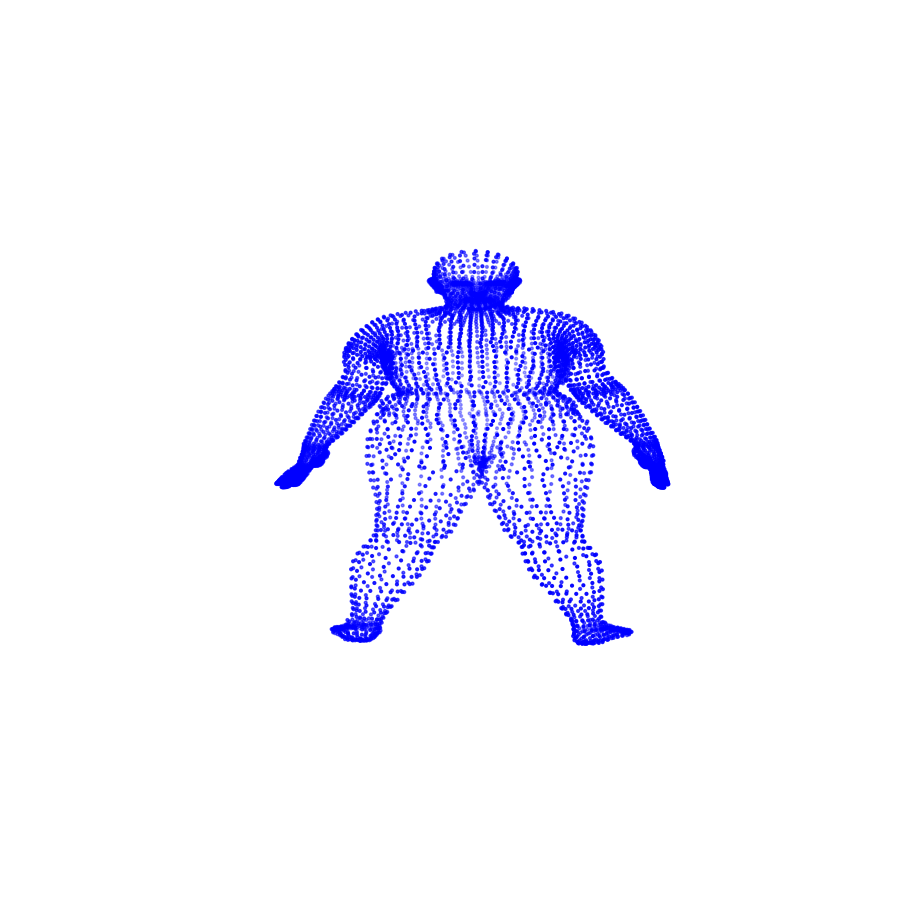

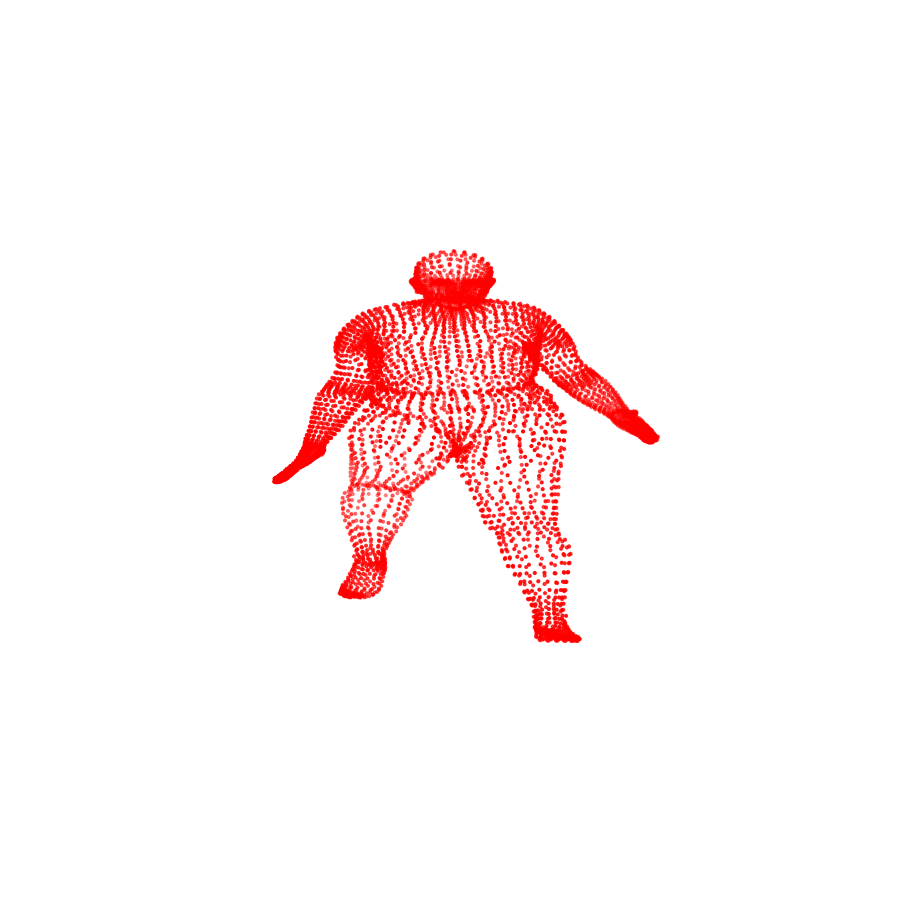

In [ ]:
"""Viusalising the point clouds."""

vis_pointcloud(V1, color="blue", axis="minimal", figsize=(9, 9), azim=90, elev=-90)
vis_pointcloud(V2, color="red", axis="minimal", figsize=(9, 9), azim=90, elev=-90)

In [ ]:
"""Calculating the Gaussian similarity matrix for the point cloud data."""

W_1 = gaussian_full_similarity(X=V1, epsilon=0.5)
W_2 = gaussian_full_similarity(X=V2, epsilon=0.5)

In [ ]:
"""Embedding the point clouds."""

Psi_1, evals_1, right_evec_1 = embed(W=W_1, t=1, Markov=False, right_evec=True)
Psi_2, evals_2, right_evec_2 = embed(W=W_2, t=1, Markov=False, right_evec=True)

In [ ]:
signs = np.sign(np.sum(Psi_1 * Psi_2, axis=0))
signs[signs == 0] = 1.0
Psi_2_aligned = Psi_2 * signs[None, :]

/Users/riki_home/Documents/Thesis/Code_final/src/plot/visualise_embedding.py:165: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(markerscale=5)


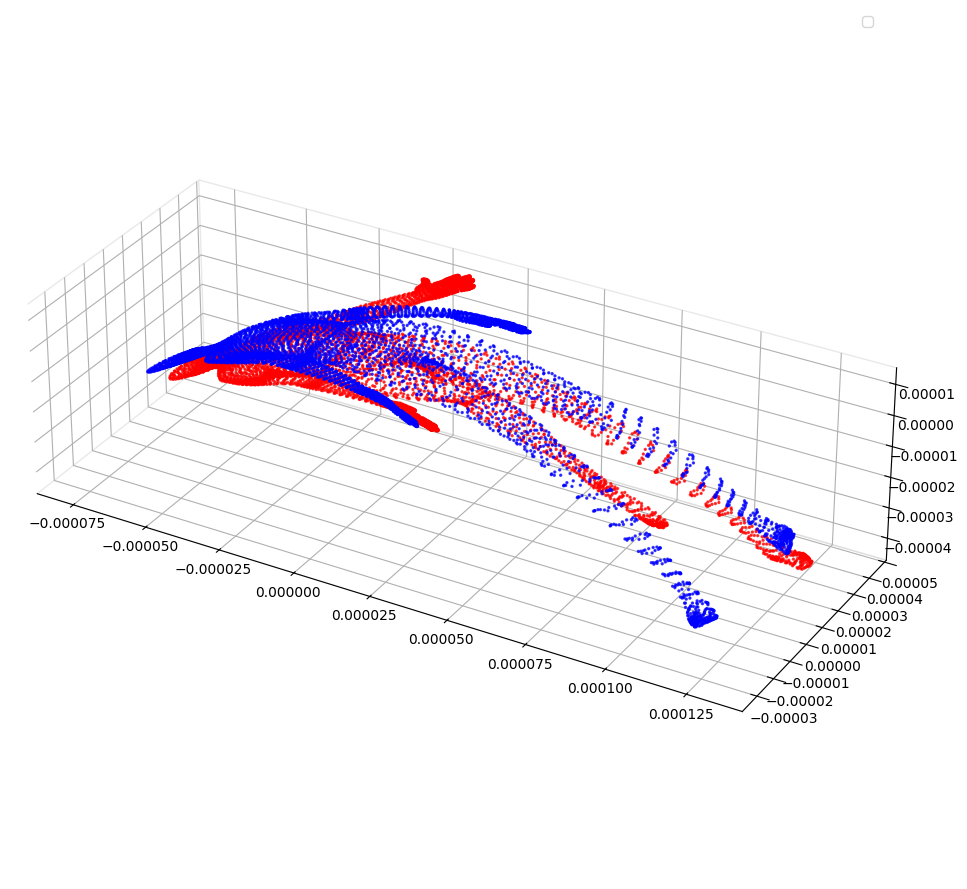

In [ ]:
"""Overlapping embeddings."""

vis_embedding_pair(
    Psi_1,
    Psi_2_aligned,
    dim=3,
    label_X=None,
    label_Y=None,
    cols=(0, 1),
    color_X="blue",
    color_Y="red",
    figsize=(9, 9),
)

Calculating similarities

In [ ]:
"""Similrity between original datasets + original vs shifted forward."""

shift_vector = np.array([100.0, 0.0, 0.0])

V2_transformed = shift_pointcloud(X=V2, shift_vector=shift_vector)

# V1 vs V2
print(f"Absolute error between V1, V2: {calculate_similarity(V1, V2)}")

# # V1 vs V2_transformed
# print(
#     f"Absolute error between V1, V2_transformed: {calculate_similarity(V1, V2_transformed)}"
# )

# V1_embedded vs V2_embedded
print(
    f"Absolute error between V1_embedded, V2_embedded: {calculate_similarity(Psi_1, Psi_2_aligned)}"
)

Absolute error between V1, V2: 1078.3150690180355
Absolute error between V1_embedded, V2_embedded: 0.08955200714795032
